# Gene Expression - evaluacija i poređenje klasifikatora 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV


##  Ucitavanje rezultata svih algoritama

In [31]:
algo_files = {
    'Logisticka regresija':  'logistic_regression_all_results.csv',
    'Naive Bayes':           'naive_bayes_all_results.csv',
    'XGBoost':               'xgboost_all_results.csv',
    'Random Forest':         'random_forest_all_results.csv',
    'Linear SVM':            'linear_svm_all_results.csv',
    'k-NN':                  'knn_all_results.csv'
}

frames = []
for algo, path in algo_files.items():
    df = pd.read_csv(path)
    df['algorithm'] = algo
    frames.append(df)
        
all_results = pd.concat(frames, ignore_index=True)


## Sveobuhvatna tabela poredjenja. Najbolja konfiguracija po algoritmu i po skupu

In [32]:
best_per_algo_file = (
    all_results
    .loc[all_results.groupby(['algorithm', 'file'])['test_f1'].idxmax()]
    [['algorithm', 'file', 'test_f1', 'test_accuracy', 'mean_cv_f1', 'mean_cv_accuracy']]
    .sort_values('test_f1', ascending=False)
    .reset_index(drop=True)
)

pd.set_option('display.float_format', '{:.4f}'.format)
print('=== TOP 15 KONFIGURACIJA (po Test F1) ===')
top15 = best_per_algo_file.head(15).copy()
top15.index += 1
print(top15.to_string())

=== TOP 15 KONFIGURACIJA (po Test F1) ===
               algorithm                     file  test_f1  test_accuracy  mean_cv_f1  mean_cv_accuracy
1          Random Forest  data_top200_genes_smote   0.9921         0.9921      0.0000            0.9820
2          Random Forest  data_top100_genes_smote   0.9904         0.9905      0.0000            0.9778
3                XGBoost  data_top100_genes_smote   0.9890         0.9889      0.9804            0.9804
4          Random Forest   data_top30_genes_smote   0.9889         0.9889      0.0000            0.9677
5          Random Forest   data_top50_genes_smote   0.9889         0.9889      0.0000            0.9756
6                   k-NN   data_top50_genes_smote   0.9843         0.9841      0.0000            0.9571
7          Random Forest   data_top40_genes_smote   0.9841         0.9841      0.0000            0.9762
8          Random Forest        data_pca70_smoted   0.9840         0.9841      0.0000            0.9666
9                XGBoo

In [33]:
print('\n=== NAJBOLJI MODEL PO ALGORITMU ===')
best_per_algo = (
    best_per_algo_file
    .groupby('algorithm', as_index=False)
    .first()
    .sort_values('test_f1', ascending=False)
    .reset_index(drop=True)
)
best_per_algo.index += 1
print(best_per_algo.to_string())


=== NAJBOLJI MODEL PO ALGORITMU ===
              algorithm                     file  test_f1  test_accuracy  mean_cv_f1  mean_cv_accuracy
1         Random Forest  data_top200_genes_smote   0.9921         0.9921      0.0000            0.9820
2               XGBoost  data_top100_genes_smote   0.9890         0.9889      0.9804            0.9804
3                  k-NN   data_top50_genes_smote   0.9843         0.9841      0.0000            0.9571
4  Logisticka regresija        data_pca70_smoted   0.9795         0.9794      0.0000            0.9666
5            Linear SVM        data_pca70_smoted   0.9780         0.9778      0.0000            0.9687
6           Naive Bayes               data_smote   0.9685         0.9683      0.0000            0.9672


## Vizuelizacija - heatmapa F1 (algoritam x skup). Za svaki par (algoritam, skup) prikazujemo najbolji F1 koji je algoritam postigao na tom skupu

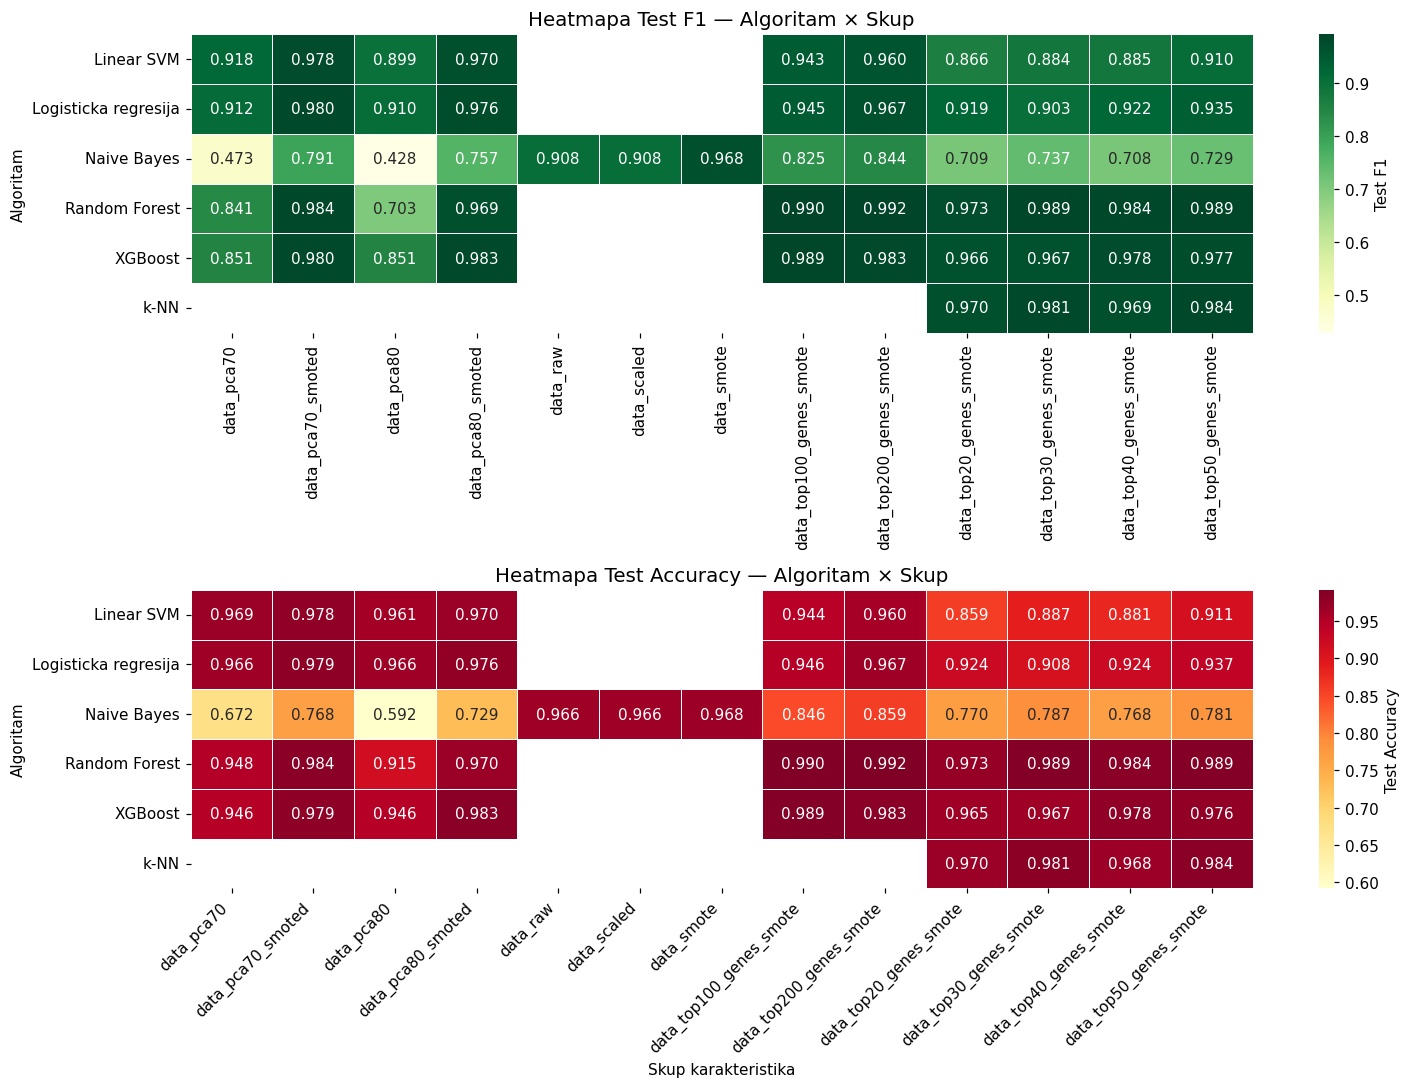

In [34]:
pivot_f1 = best_per_algo_file.pivot_table(
    values='test_f1', index='algorithm', columns='file', aggfunc='max'
)
pivot_acc = best_per_algo_file.pivot_table(
    values='test_accuracy', index='algorithm', columns='file', aggfunc='max'
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Test F1'})
axes[0].set_title('Heatmapa Test F1 — Algoritam × Skup', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Algoritam')

sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Test Accuracy'})
axes[1].set_title('Heatmapa Test Accuracy — Algoritam × Skup', fontsize=13)
axes[1].set_xlabel('Skup karakteristika')
axes[1].set_ylabel('Algoritam')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Bar grafikon - najbolji model po algoritmu

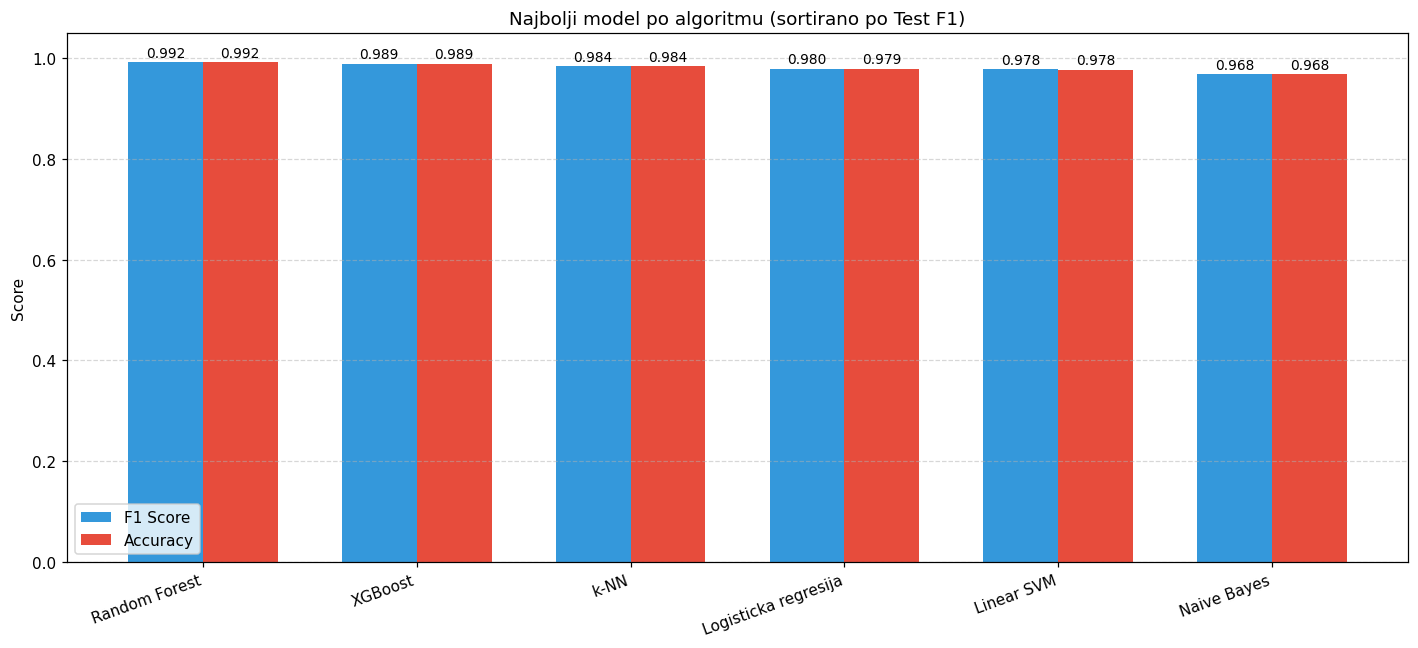

In [35]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(best_per_algo))
width = 0.35

bars1 = ax.bar(x - width/2, best_per_algo['test_f1'],       width, label='F1 Score', color='#3498db')
bars2 = ax.bar(x + width/2, best_per_algo['test_accuracy'], width, label='Accuracy', color='#e74c3c')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(best_per_algo['algorithm'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Najbolji model po algoritmu (sortirano po Test F1)')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

##  Krive svih konfiguracija - boxplot po algoritmu

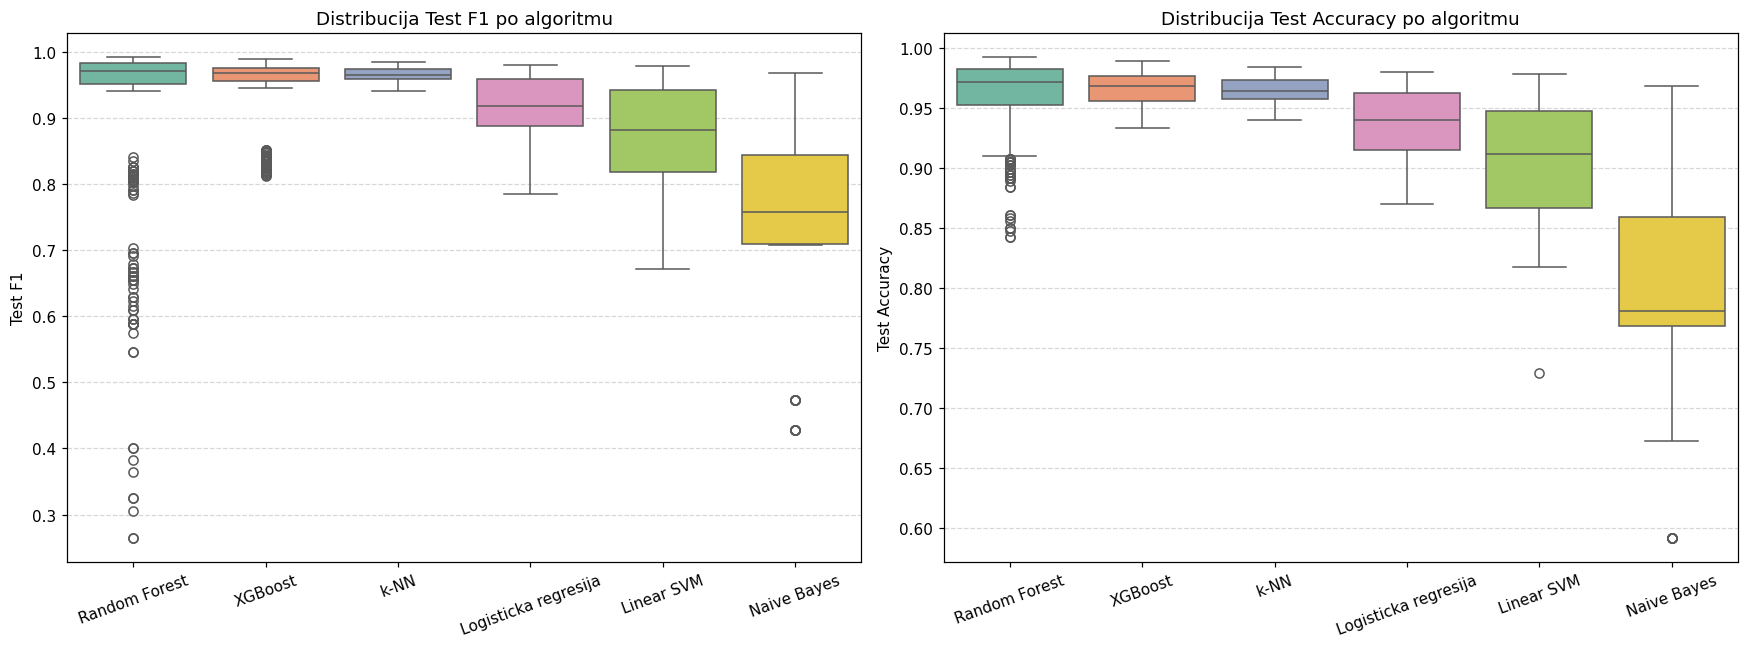

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = best_per_algo['algorithm'].tolist()

sns.boxplot(data=all_results, x='algorithm', y='test_f1', ax=axes[0],
            order=order, palette='Set2')
axes[0].set_title('Distribucija Test F1 po algoritmu')
axes[0].set_xlabel('')
axes[0].set_ylabel('Test F1')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=all_results, x='algorithm', y='test_accuracy', ax=axes[1],
            order=order, palette='Set2')
axes[1].set_title('Distribucija Test Accuracy po algoritmu')
axes[1].set_xlabel('')
axes[1].set_ylabel('Test Accuracy')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Najbolji model ukupno. Identifikujemo apsolutno najbolji model (po Test F1), retreniramo ga na njegovom skupu i analiziramo

In [37]:
best_overall = best_per_algo_file.iloc[0]
print(f'NAJBOLJI MODEL UKUPNO:')
print(f'  Algoritam:    {best_overall["algorithm"]}')
print(f'  Skup:         {best_overall["file"]}')
print(f'  Test F1:      {best_overall["test_f1"]:.4f}')
print(f'  Test Acc:     {best_overall["test_accuracy"]:.4f}')
print(f'  Mean CV F1:   {best_overall["mean_cv_f1"]:.4f}')

# Vrati pune parametre tog modela iz all_results
algo = best_overall['algorithm']
file = best_overall['file']
full_row = all_results[(all_results['algorithm'] == algo) & (all_results['file'] == file)]
full_row = full_row.loc[full_row['test_f1'].idxmax()]
print(f'\nParametri modela:')
for k, v in full_row.items():
    if k not in ('algorithm', 'file', 'test_f1', 'test_accuracy', 'mean_cv_f1', 'mean_cv_accuracy'):
        if pd.notna(v):
            print(f'  {k} = {v}')

NAJBOLJI MODEL UKUPNO:
  Algoritam:    Random Forest
  Skup:         data_top200_genes_smote
  Test F1:      0.9921
  Test Acc:     0.9921
  Mean CV F1:   0.0000

Parametri modela:
  n_estimators = 50.0
  max_depth = 10.0
  min_samples_split = 5.0


In [38]:
# Ponovo treniraj najbolji model i analiziraj na test skupu
df = pd.read_csv(f'data/{file}.csv')
X = df.drop('target', axis=1)
y = df['target']

label_map = {'Other': 0, 'Colon': 1} if algo == 'XGBoost' else None
if label_map:
    y = y.map(label_map)
pos_label = 1 if label_map else 'Colon'

X_tr, X_te, y_tr, y_te = train_test_split(X, y, stratify=y, random_state=42)

# Rekonstruiši klasifikator iz najboljeg reda
def build_model(algo, row):
    if algo == 'Logistička regresija':
        return LogisticRegression(C=row['C'], penalty=row['penalty'],
                                  solver=row['solver'], max_iter=1000)
    if algo == 'Naive Bayes':
        return GaussianNB(var_smoothing=row['var_smoothing'])
    if algo == 'XGBoost':
        return XGBClassifier(
            n_estimators=int(row['n_estimators']),
            max_depth=int(row['max_depth']),
            learning_rate=row['learning_rate'],
            eval_metric='logloss', use_label_encoder=False,
            random_state=42, verbosity=0
        )
    if algo == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=int(row['n_estimators']),
            max_depth=None if pd.isna(row['max_depth']) else int(row['max_depth']),
            min_samples_split=int(row['min_samples_split']),
            random_state=42, n_jobs=-1
        )
    if algo == 'Linear SVM':
        # Wrap u CalibratedClassifierCV za predict_proba (ROC analiza)
        base = LinearSVC(C=row['C'], loss=row['loss'], max_iter=5000,
                         dual='auto', random_state=42)
        return CalibratedClassifierCV(base, cv=3)
    if algo == 'k-NN':
        return KNeighborsClassifier(
            n_neighbors=int(row['n_neighbors']),
            weights=row['weights'], metric=row['metric'], n_jobs=-1
        )
    raise ValueError(f'Nepoznat algoritam: {algo}')

model = build_model(algo, full_row)
model.fit(X_tr, y_tr)

y_pred = model.predict(X_te)
y_prob = model.predict_proba(X_te)[:, list(model.classes_).index(pos_label)]

print(f'\nKlasifikacioni izveštaj na test skupu:')
print(classification_report(y_te, y_pred, digits=4))


Klasifikacioni izveštaj na test skupu:
              precision    recall  f1-score   support

       Colon     0.9936    0.9905    0.9921       315
       Other     0.9905    0.9937    0.9921       315

    accuracy                         0.9921       630
   macro avg     0.9921    0.9921    0.9921       630
weighted avg     0.9921    0.9921    0.9921       630



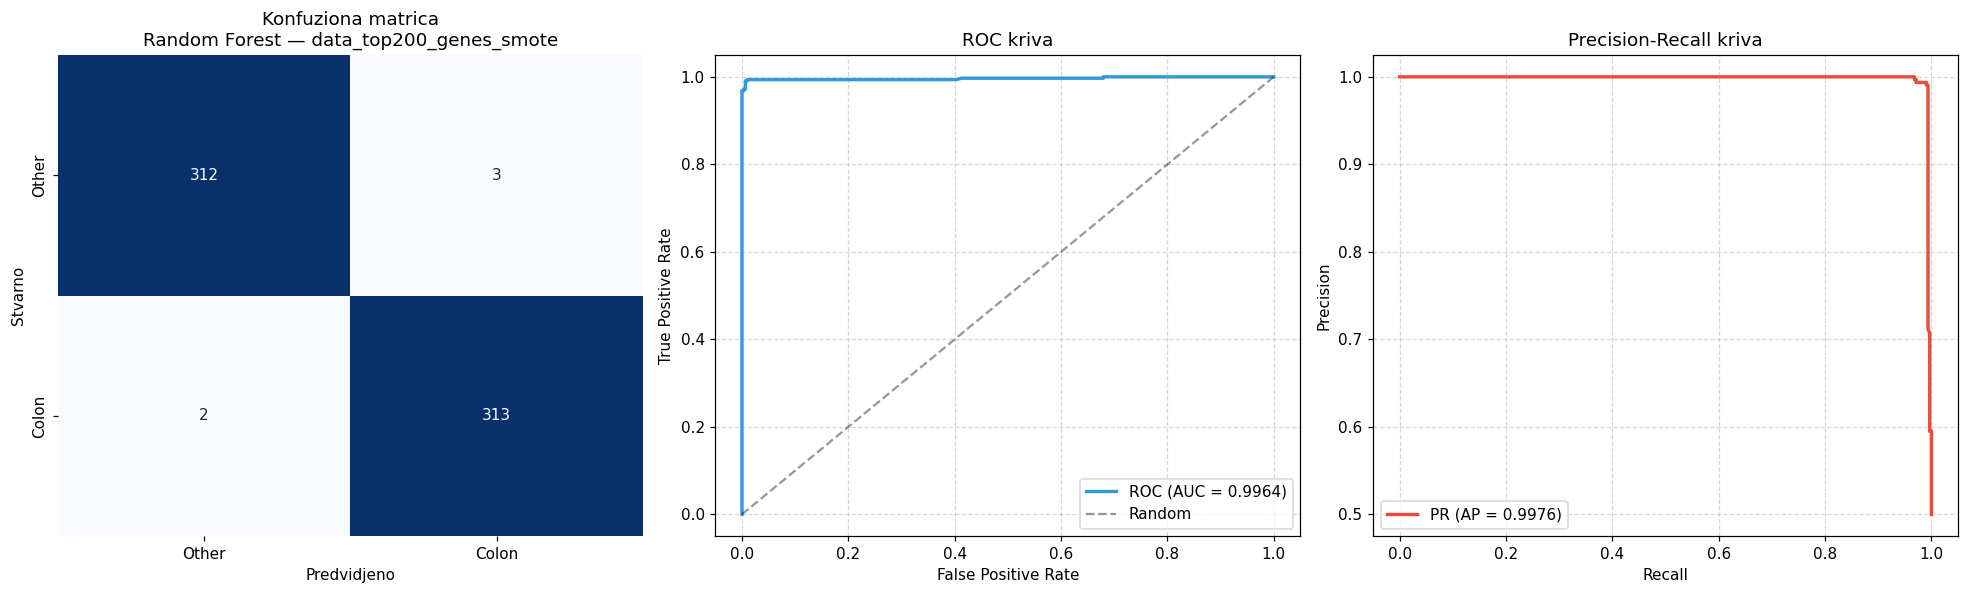

In [39]:
# Confusion matrix + ROC + PR krive na istoj figuri
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

cm = confusion_matrix(y_te, y_pred)
class_labels = ['Other', 'Colon'] if not label_map else ['Other (0)', 'Colon (1)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[0], cbar=False)
axes[0].set_xlabel('Predvidjeno')
axes[0].set_ylabel('Stvarno')
axes[0].set_title(f'Konfuziona matrica\n{algo} — {file}')

# ROC
fpr, tpr, _ = roc_curve(y_te, y_prob, pos_label=pos_label)
auc = roc_auc_score((y_te == pos_label).astype(int), y_prob)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2.2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC kriva')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

# PR
prec, rec, _ = precision_recall_curve(y_te, y_prob, pos_label=pos_label)
ap = average_precision_score((y_te == pos_label).astype(int), y_prob)
axes[2].plot(rec, prec, color='#e74c3c', linewidth=2.2, label=f'PR (AP = {ap:.4f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall kriva')
axes[2].legend(loc='lower left')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analiza F1 vs Accuracy gap-a. Veliki gap između Accuracy-ja i F1 ukazuje da model dobro hvata većinsku klasu (Other) ali pati na manjinskoj (Colon). Idealan model na nebalansiranom skupu ima **mali gap** i visok F1.

Medijana F1, Acc i gap-a po algoritmu (sortirano po gap-u):
                      median_f1  median_acc  median_gap
algorithm                                              
k-NN                     0.9757      0.9754     -0.0003
XGBoost                  0.9774      0.9770     -0.0002
Random Forest            0.9841      0.9841      0.0001
Linear SVM               0.9137      0.9524      0.0008
Logisticka regresija     0.9285      0.9562      0.0016
Naive Bayes              0.7574      0.7810      0.0515


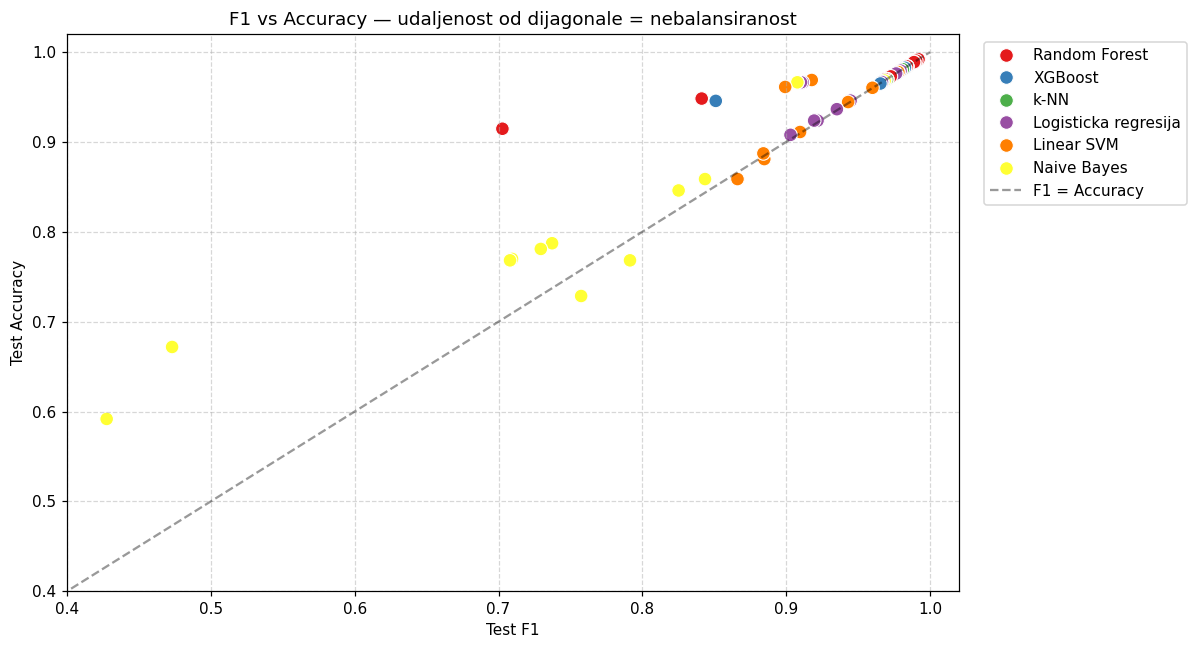

In [40]:
best_per_algo_file['gap'] = best_per_algo_file['test_accuracy'] - best_per_algo_file['test_f1']

gap_per_algo = best_per_algo_file.groupby('algorithm').agg(
    median_f1=('test_f1', 'median'),
    median_acc=('test_accuracy', 'median'),
    median_gap=('gap', 'median')
).sort_values('median_gap')
print('Medijana F1, Acc i gap-a po algoritmu (sortirano po gap-u):')
print(gap_per_algo)

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=best_per_algo_file, x='test_f1', y='test_accuracy',
    hue='algorithm', s=80, ax=ax, palette='Set1'
)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='F1 = Accuracy')
ax.set_xlim(0.4, 1.02)
ax.set_ylim(0.4, 1.02)
ax.set_xlabel('Test F1')
ax.set_ylabel('Test Accuracy')
ax.set_title('F1 vs Accuracy — udaljenost od dijagonale = nebalansiranost')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##  Krajnji zakljucak

In [42]:
print('=== KRAJNJI ZAKLJUCAK ===')
print(f'Ukupno evaluiranih algoritama:    {best_per_algo["algorithm"].nunique()}')
print(f'Ukupno (algoritam, skup) parova:  {len(best_per_algo_file)}')
print(f'Ukupno kombinacija parametara:    {len(all_results)}')
print()
print(f'NAJBOLJI ALGORITAM:    {best_overall["algorithm"]}')
print(f'NAJBOLJI SKUP:         {best_overall["file"]}')
print(f'TEST F1:               {best_overall["test_f1"]:.4f}')
print(f'TEST ACCURACY:         {best_overall["test_accuracy"]:.4f}')
print()
print('Top 3 algoritma po medijani F1 (na svojim skupovima):')
top3 = best_per_algo_file.groupby('algorithm')['test_f1'].median().sort_values(ascending=False).head(3)
for i, (algo, f1) in enumerate(top3.items(), 1):
    print(f'  {i}. {algo:<22} medijana F1 = {f1:.4f}')
print()
print('Najmanja gap (algoritam najmanje pati od nebalansiranosti):')
print(f'  {gap_per_algo.index[0]:<22} gap = {gap_per_algo.iloc[0]["median_gap"]:.4f}')

=== KRAJNJI ZAKLJUCAK ===
Ukupno evaluiranih algoritama:    6
Ukupno (algoritam, skup) parova:  57
Ukupno kombinacija parametara:    1020

NAJBOLJI ALGORITAM:    Random Forest
NAJBOLJI SKUP:         data_top200_genes_smote
TEST F1:               0.9921
TEST ACCURACY:         0.9921

Top 3 algoritma po medijani F1 (na svojim skupovima):
  1. Random Forest          medijana F1 = 0.9841
  2. XGBoost                medijana F1 = 0.9774
  3. k-NN                   medijana F1 = 0.9757

Najmanja gap (algoritam najmanje pati od nebalansiranosti):
  k-NN                   gap = -0.0003
